<a href="https://colab.research.google.com/github/Yeswanth0426/computervision_/blob/main/Pose%20Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
!pip install mediapipe==0.10.14

In [3]:
from google.colab import files
uploaded = files.upload(/content/original-3df54df7ba37b98424d7e3ea68be340f.gif)

SyntaxError: invalid decimal literal (2261744130.py, line 2)

In [4]:
import os
print(os.listdir())

['.config', 'original-3df54df7ba37b98424d7e3ea68be340f.gif', 'sample_data']


In [5]:
import mediapipe as mp
print("MediaPipe version:", mp._version_)
print("Has solutions:", hasattr(mp, "solutions"))

AttributeError: module 'mediapipe' has no attribute '_version_'

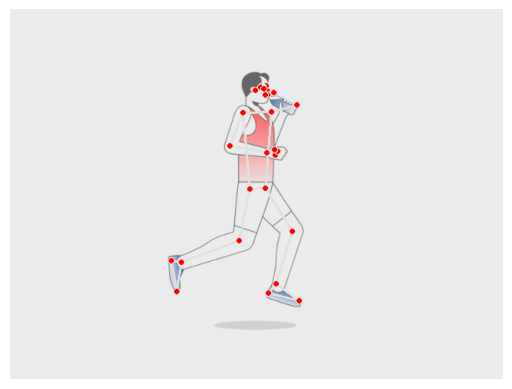

In [ ]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Initialize MediaPipe
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5,
                    min_tracking_confidence=0.5)
mp_drawing = mp.solutions.drawing_utils

def estimate_pose_from_video(video_path, width=640, height=480):
    cap = cv2.VideoCapture(video_path)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Resize frame
        frame_resized = cv2.resize(frame, (width, height))

        # Convert to RGB
        frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)

        # Pose detection
        results = pose.process(frame_rgb)

        # Draw skeleton
        if results.pose_landmarks:
            mp_drawing.draw_landmarks(
                frame_resized,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS
            )

        # Display in Colab
        plt.imshow(cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        display(plt.gcf())
        clear_output(wait=True)

    cap.release()

# ⚠️ VERY IMPORTANT — change filename here
video_path = "/content/original-3df54df7ba37b98424d7e3ea68be340f.gif"
estimate_pose_from_video(video_path)